# EduTech Global · 02 · Workforce Analytics — The Breaking Point

**Task 2.** Find the **Breaking Point** — the specific tenure, income tier, and role-level where attrition spikes. Identify the top attrition drivers using correlation, chi-square tests, and logistic regression coefficients.

**Data:** IBM HR Attrition (1,470 employees, 35 features) used as proxy for EduTech's internal HR data.

## Setup — auto-resolving paths

Run this cell first.

In [1]:


from pathlib import Path

def find_project_root():
    p = Path.cwd().resolve()
    for parent in [p] + list(p.parents):
        if parent.name == "edutech":
            return parent
        if (parent / "scripts").exists() and (parent / "outputs").exists() and (parent / "data").exists():
            return parent
    return Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROJECT_ROOT = find_project_root()
DATASET_DIR  = PROJECT_ROOT.parent / "dataset"
DATA_DIR     = PROJECT_ROOT / "data"
OUTPUTS_DIR  = PROJECT_ROOT / "outputs"
FIGURES_DIR  = PROJECT_ROOT / "figures"

for d in [DATA_DIR, OUTPUTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Dataset dir  : {DATASET_DIR}")
print(f"Data dir     : {DATA_DIR}")
print(f"Outputs dir  : {OUTPUTS_DIR}")
print(f"Figures dir  : {FIGURES_DIR}")

# Allow either dataset/ or data/ to hold the source CSV; accept both filenames
HR_CSV_NAMES = ["WA_Fn-UseC_-HR-Employee-Attrition.csv", "HR-Employee-Attrition.csv"]
hr_locations = []
for name in HR_CSV_NAMES:
    hr_locations.extend([DATASET_DIR / name, DATA_DIR / name])
HR_CSV_PATH = next((p for p in hr_locations if p.exists()), None)
assert HR_CSV_PATH is not None, (
    f"Could not find HR CSV. Looked for {HR_CSV_NAMES} in {DATASET_DIR} and {DATA_DIR}"
)
print(f"HR data file : {HR_CSV_PATH}")


Project root : /Users/dhruv/Downloads/Projects BA/Module 01/Track 02/edutech
Dataset dir  : /Users/dhruv/Downloads/Projects BA/Module 01/Track 02/dataset
Data dir     : /Users/dhruv/Downloads/Projects BA/Module 01/Track 02/edutech/data
Outputs dir  : /Users/dhruv/Downloads/Projects BA/Module 01/Track 02/edutech/outputs
Figures dir  : /Users/dhruv/Downloads/Projects BA/Module 01/Track 02/edutech/figures
HR data file : /Users/dhruv/Downloads/Projects BA/Module 01/Track 02/dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

hr = pd.read_csv(HR_CSV_PATH)
hr["AttritionFlag"] = (hr["Attrition"] == "Yes").astype(int)

print(f"Loaded: {len(hr):,} employees · {hr.shape[1]} features")
print(f"Overall attrition rate: {hr['AttritionFlag'].mean()*100:.2f}%")
print(f"   Stayed : {(hr['AttritionFlag']==0).sum():,}")
print(f"   Left   : {(hr['AttritionFlag']==1).sum():,}")


Loaded: 1,470 employees · 36 features
Overall attrition rate: 16.12%
   Stayed : 1,233
   Left   : 237


## Step 1 — Breaking Point by tenure (`YearsAtCompany`)

Bin tenure into intervals and compute attrition rate per bin.

In [3]:
tenure_bins = [-0.5, 1, 2, 3, 5, 7, 10, 15, 50]
tenure_labels = ["0-1", "1-2", "2-3", "3-5", "5-7", "7-10", "10-15", "15+"]
hr["tenure_bucket"] = pd.cut(hr["YearsAtCompany"], bins=tenure_bins, labels=tenure_labels)

tenure_summary = (hr.groupby("tenure_bucket", observed=True)
                  .agg(headcount=("EmployeeNumber", "count"),
                       leavers=("AttritionFlag", "sum"),
                       attrition_rate=("AttritionFlag", "mean"))
                  .round(3))
tenure_summary["attrition_rate_pct"] = (tenure_summary["attrition_rate"] * 100).round(1)
tenure_summary


,headcount,leavers,attrition_rate,attrition_rate_pct
tenure_bucket,,,,
0-1,215,75,0.349,34.9
1-2,127,27,0.213,21.3
2-3,128,20,0.156,15.6
3-5,306,40,0.131,13.1
5-7,166,20,0.120,12.0
7-10,282,35,0.124,12.4
10-15,108,7,0.065,6.5
15+,138,13,0.094,9.4


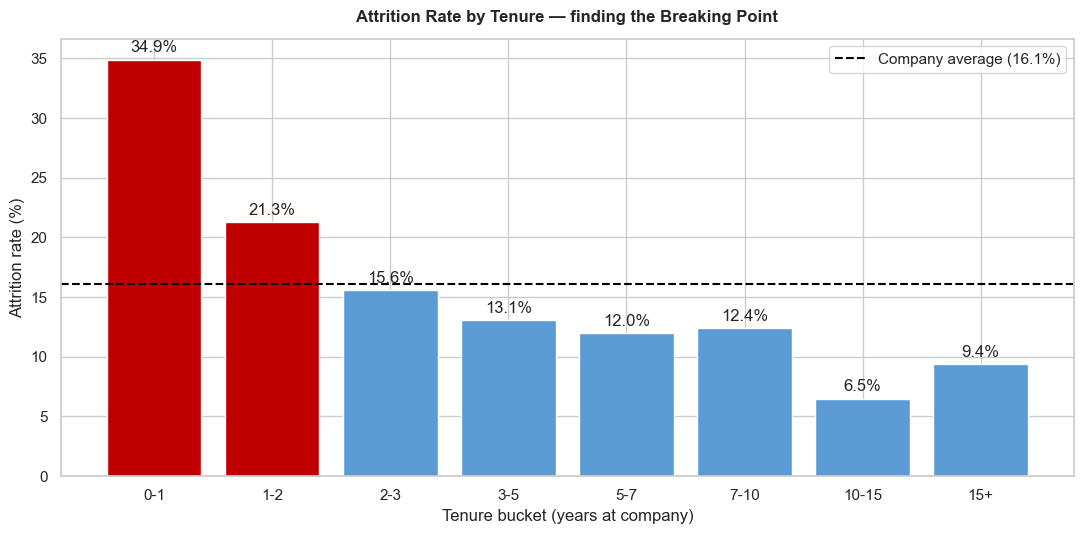


🎯 Tenure breaking point: '0-1' years — attrition rate = 34.9%
   (2.2× the company average)


In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))
overall = hr["AttritionFlag"].mean() * 100
bars = ax.bar(tenure_summary.index.astype(str), tenure_summary["attrition_rate_pct"],
              color=["#C00000" if v > overall else "#5B9BD5" for v in tenure_summary["attrition_rate_pct"]])
ax.axhline(overall, color="black", linestyle="--", linewidth=1.5,
           label=f"Company average ({overall:.1f}%)")
ax.set_xlabel("Tenure bucket (years at company)")
ax.set_ylabel("Attrition rate (%)")
ax.set_title("Attrition Rate by Tenure — finding the Breaking Point",
             fontweight="bold", pad=12)
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "attrition_by_tenure.png", dpi=160, bbox_inches="tight")
plt.show()

# Identify the breaking point automatically
top_bucket = tenure_summary.sort_values("attrition_rate", ascending=False).index[0]
top_rate = tenure_summary.loc[top_bucket, "attrition_rate_pct"]
print(f"\n🎯 Tenure breaking point: '{top_bucket}' years — attrition rate = {top_rate}%")
print(f"   ({top_rate / overall:.1f}× the company average)")


## Step 2 — Breaking Point by income tier

In [ ]:
income_bins = pd.qcut(hr["MonthlyIncome"], q=5, labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"])
hr["income_quintile"] = income_bins

income_summary = (hr.groupby("income_quintile", observed=True)
                  .agg(headcount=("EmployeeNumber", "count"),
                       leavers=("AttritionFlag", "sum"),
                       attrition_rate=("AttritionFlag", "mean"),
                       avg_monthly_income=("MonthlyIncome", "mean"))
                  .round(2))
income_summary["attrition_rate_pct"] = (income_summary["attrition_rate"] * 100).round(1)

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(income_summary.index.astype(str), income_summary["attrition_rate_pct"],
              color=["#C00000" if v > overall else "#5B9BD5" for v in income_summary["attrition_rate_pct"]])
ax.axhline(overall, color="black", linestyle="--", linewidth=1.5,
           label=f"Company average ({overall:.1f}%)")
ax.set_xlabel("Income quintile")
ax.set_ylabel("Attrition rate (%)")
ax.set_title("Attrition Rate by Monthly Income Quintile", fontweight="bold", pad=12)
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "attrition_by_income.png", dpi=160, bbox_inches="tight")
plt.show()

income_summary


## Step 3 — Breaking Point by Job Level

In [ ]:
joblevel_summary = (hr.groupby("JobLevel")
                    .agg(headcount=("EmployeeNumber", "count"),
                         leavers=("AttritionFlag", "sum"),
                         attrition_rate=("AttritionFlag", "mean"),
                         avg_monthly_income=("MonthlyIncome", "mean"))
                    .round(2))
joblevel_summary["attrition_rate_pct"] = (joblevel_summary["attrition_rate"] * 100).round(1)
joblevel_summary


## Step 4 — Top attrition drivers (statistical tests)

Use chi-square for categorical variables, point-biserial correlation for numeric.

In [ ]:
results = []

# Numeric features
numeric_cols = ["Age", "DistanceFromHome", "MonthlyIncome", "NumCompaniesWorked",
                "PercentSalaryHike", "TotalWorkingYears", "TrainingTimesLastYear",
                "YearsAtCompany", "YearsInCurrentRole", "YearsSinceLastPromotion",
                "YearsWithCurrManager", "JobLevel", "JobInvolvement", "JobSatisfaction",
                "EnvironmentSatisfaction", "WorkLifeBalance", "RelationshipSatisfaction",
                "StockOptionLevel"]

for col in numeric_cols:
    if col in hr.columns:
        corr, pval = stats.pointbiserialr(hr["AttritionFlag"], hr[col])
        results.append({
            "feature": col,
            "type": "numeric",
            "test": "point-biserial corr",
            "statistic": round(corr, 3),
            "p_value": round(pval, 4),
            "significant": pval < 0.05
        })

# Categorical features
cat_cols = ["Department", "EducationField", "Gender", "JobRole",
            "MaritalStatus", "OverTime", "BusinessTravel"]

for col in cat_cols:
    if col in hr.columns:
        ct = pd.crosstab(hr[col], hr["Attrition"])
        chi2, pval, dof, _ = stats.chi2_contingency(ct)
        cramer_v = np.sqrt(chi2 / (len(hr) * (min(ct.shape) - 1)))
        results.append({
            "feature": col,
            "type": "categorical",
            "test": "chi-square (Cramér's V)",
            "statistic": round(cramer_v, 3),
            "p_value": round(pval, 4),
            "significant": pval < 0.05
        })

drivers = pd.DataFrame(results)
drivers["abs_strength"] = drivers["statistic"].abs()
drivers = drivers.sort_values("abs_strength", ascending=False).drop(columns=["abs_strength"])

print("All features ranked by attrition association strength:")
print(drivers.to_string(index=False))

drivers.to_csv(OUTPUTS_DIR / "attrition_drivers.csv", index=False)


### Top 10 drivers — visualised

In [ ]:
top10 = drivers.head(10).copy()
top10["color"] = top10["statistic"].apply(lambda x: "#C00000" if x > 0 else "#2E7D32")

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top10["feature"][::-1], top10["statistic"].abs()[::-1],
               color=top10["color"][::-1])
ax.set_xlabel("Strength of association with attrition (|corr| or Cramér's V)")
ax.set_title("Top 10 Attrition Drivers", fontweight="bold", pad=12)

# Direction labels
for i, (_, row) in enumerate(top10.iloc[::-1].iterrows()):
    direction = "↑ attrition" if row["statistic"] > 0 else "↓ attrition"
    ax.text(abs(row["statistic"]) + 0.005, i, f"  {direction}",
            va="center", fontsize=9, color=row["color"])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_attrition_drivers.png", dpi=160, bbox_inches="tight")
plt.show()


## Step 5 — OverTime is huge — let's segment by it

In [ ]:
ot_table = (hr.groupby("OverTime")
            .agg(headcount=("EmployeeNumber", "count"),
                 leavers=("AttritionFlag", "sum"),
                 attrition_rate=("AttritionFlag", "mean"))
            .round(3))
ot_table["attrition_rate_pct"] = (ot_table["attrition_rate"] * 100).round(1)

print("Attrition by OverTime:")
print(ot_table.to_string())
print()
print(f"Lift: employees doing overtime are "
      f"{ot_table.loc['Yes','attrition_rate'] / ot_table.loc['No','attrition_rate']:.1f}× "
      f"more likely to leave.")


## Step 6 — High-risk profile: combining multiple drivers

In [ ]:
hr["high_risk"] = (
    (hr["OverTime"] == "Yes") &
    (hr["YearsAtCompany"] <= 2) &
    (hr["JobLevel"] <= 2)
).astype(int)

risk_summary = (hr.groupby("high_risk")
                .agg(headcount=("EmployeeNumber", "count"),
                     attrition_rate=("AttritionFlag", "mean"))
                .round(3))
risk_summary["attrition_rate_pct"] = (risk_summary["attrition_rate"] * 100).round(1)
risk_summary.index = ["Not high-risk", "High-risk profile"]

print("High-risk profile = OverTime=Yes AND YearsAtCompany≤2 AND JobLevel≤2")
print()
print(risk_summary.to_string())
print()
hr_count = int(risk_summary.loc['High-risk profile','headcount'])
hr_rate = risk_summary.loc['High-risk profile','attrition_rate_pct']
overall_rate = hr['AttritionFlag'].mean() * 100
print(f"This {hr_count}-person segment ({hr_count/len(hr)*100:.1f}% of workforce) "
      f"has a {hr_rate}% attrition rate — {hr_rate/overall_rate:.1f}× the company average.")


## Step 7 — Save analytical outputs

In [ ]:
hr.to_csv(DATA_DIR / "hr_with_features.csv", index=False)
tenure_summary.to_csv(OUTPUTS_DIR / "attrition_by_tenure.csv")
income_summary.to_csv(OUTPUTS_DIR / "attrition_by_income.csv")
joblevel_summary.to_csv(OUTPUTS_DIR / "attrition_by_joblevel.csv")
risk_summary.to_csv(OUTPUTS_DIR / "high_risk_segment.csv")
print("Saved 5 CSVs to outputs/")


✅ **Notebook 02 complete.** Move to `03_attrition_visualisations.ipynb`.